In [3]:
import numpy as np

def filter_outliers(data, k = 1.5, return_idx = False, method = 'iqr'):
    """Remove outliers outside [Q1 - k*IQR, Q3 + k*IQR]."""
    data = np.asarray(data)
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    mask = (data >= lower) & (data <= upper)
    if return_idx:
        return np.where(mask)[0], data[mask]
    else:
        return data[mask]

Preprocess CAR entries from InterPro DB
----------------------------------------

In [ ]:
import numpy as np
import pandas as pd

from collections import defaultdict
from Bio import SeqIO

fasta_path = 'car_interpro.fasta'

seq_to_records = defaultdict(list)

for record in SeqIO.parse(fasta_path, "fasta"):
    desc = record.description.split('|')
    uniprot_id = desc[0]
    is_reviewed = desc[1]
    function = desc[2]
    tax_id = desc[3]
    seq = str(record.seq)  # cast to str so it is hashable as a dict key
    
    seq_to_records[seq].append((uniprot_id, is_reviewed, function, tax_id))

# Build DataFrame: one row per unique sequence
rows = []
for seq, members in seq_to_records.items():
    uniprot_ids = [m[0] for m in members]
    
    reviewed_ids = [uid for uid, status, _, _ in members if status == 'reviewed']
    is_reviewed = f"reviewed ({','.join(reviewed_ids)})" if reviewed_ids else 'unreviewed'
    
    rows.append({
        'uniprot_id': ';'.join(uniprot_ids),
        'is_reviewed': is_reviewed,
        'function': ';'.join(set(m[2] for m in members)),
        'tax_id': ';'.join(m[3] for m in members),
        'length': len(seq),
        'sequence': seq,
    })

df_interpro = pd.DataFrame(rows)

print(f'Redundace: {len(list(SeqIO.parse(fasta_path, "fasta")))}, None-redundance: {len(df_interpro)}')
df_interpro

Redundace: 1026, None-redundance: 986


,uniprot_id,is_reviewed,function,tax_id,length,sequence
0,A0A010YLP6,unreviewed,Carrier domain-containing protein,taxID:927661,1152,MTHTDQGDVTTVAERRALLLEQDEQFASAVPDDHVTALVRQPTMSL...
1,A0A024JSK2,unreviewed,Carboxylic acid reductase,taxID:47839,1188,MTTDMKRENGTNSTTKATPRERVAERIRRVEATDEQYRNAKPDQAL...
2,A0A024JWI0,unreviewed,Carboxylic acid reductase,taxID:47839,1162,MSTTTREERLERRIENLTATDPQFAAAKPDPAVVEALEQPGLQLPQ...
3,A0A024JZE3,unreviewed,Carboxylic acid reductase,taxID:47839,1165,MAFVGRSDVKDPGAQQDQWERLARRRERLYAEDAQFAATRPDEQIA...
4,A0A024JZE8,unreviewed,Carboxylic acid reductase,taxID:47839,1182,MTSGSLRDIHLAEPGDNRDERTAQRVAELFDNDPQFRAAAPLPDVI...
...,...,...,...,...,...,...
981,X8CEN6,unreviewed,Carboxylic acid reductase,taxID:1299331,1162,MAATDEQFRNAQPDLSLQQAARQPGLRLPQILELFVEGYADRPAVG...
982,X8CIS2,unreviewed,Carboxylic acid reductase,taxID:1299331,1072,MSTAIHDENLDRRIEELIANDPQFAAARPDPAITAATEAPGLRLPQ...
983,X8DPU6,unreviewed,Carboxylic acid reductase,taxID:1299321,1183,MTIDATADNTKEARRQRLGDRVRRLFTEDEQFRAAKPDTAVDAAVA...
984,X8DT62,unreviewed,Carrier domain-containing protein,taxID:1299321,902,MAGTENLPMIGLNFMPMSHIMGRGTLTSTLSTGGTGYFAASSDMST...


In [5]:
idx, values = filter_outliers(df_interpro['length'], return_idx = True)
df_filtered = df_interpro.iloc[idx]
df_filtered

,uniprot_id,is_reviewed,function,tax_id,length,sequence
0,A0A010YLP6,unreviewed,Carrier domain-containing protein,taxID:927661,1152,MTHTDQGDVTTVAERRALLLEQDEQFASAVPDDHVTALVRQPTMSL...
1,A0A024JSK2,unreviewed,Carboxylic acid reductase,taxID:47839,1188,MTTDMKRENGTNSTTKATPRERVAERIRRVEATDEQYRNAKPDQAL...
2,A0A024JWI0,unreviewed,Carboxylic acid reductase,taxID:47839,1162,MSTTTREERLERRIENLTATDPQFAAAKPDPAVVEALEQPGLQLPQ...
3,A0A024JZE3,unreviewed,Carboxylic acid reductase,taxID:47839,1165,MAFVGRSDVKDPGAQQDQWERLARRRERLYAEDAQFAATRPDEQIA...
4,A0A024JZE8,unreviewed,Carboxylic acid reductase,taxID:47839,1182,MTSGSLRDIHLAEPGDNRDERTAQRVAELFDNDPQFRAAAPLPDVI...
...,...,...,...,...,...,...
979,X0Q040,unreviewed,Carboxylic acid reductase,taxID:1219028,1175,MSTDIREERLARRIADLYANDRQFVAARPSEALTAAIEQPGLRLPQ...
980,X8A9W7;X8CDI5,unreviewed,Carboxylic acid reductase,taxID:1767;taxID:1299331,1188,MTDTVTDSGREQRLTERVEQLYANDPQFRAAAPSPEVTEAAHRAGL...
981,X8CEN6,unreviewed,Carboxylic acid reductase,taxID:1299331,1162,MAATDEQFRNAQPDLSLQQAARQPGLRLPQILELFVEGYADRPAVG...
983,X8DPU6,unreviewed,Carboxylic acid reductase,taxID:1299321,1183,MTIDATADNTKEARRQRLGDRVRRLFTEDEQFRAAKPDTAVDAAVA...


Load the PDB files of the CAR homologs by parsing the UniProt
--

In [ ]:
import requests
import os
import time

from tqdm.notebook import tqdm
# Load data 
# `df` is the deduplicated DataFrame from the previous step
# (uniprot_id column may hold comma-separated IDs that share the same sequence)
print(f"Total unique sequences: {len(df_filtered)}")
os.makedirs("structures", exist_ok=True)

def get_alphafold_pdb_url(uniprot_id: str) -> str:
    """
    Query AlphaFold EBI API to get the actual PDB download URL.
    The API returns metadata including 'pdbUrl' which points to the exact file.
    This avoids hardcoding version numbers (v1/v2/v3/v4).
    
    API endpoint: https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}
    """
    url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    res = requests.get(url, timeout=10)
    if res.status_code != 200:
        return None
    data = res.json()
    if not data:
        return None
    return data[0].get("pdbUrl")

def download_structure(pdb_url: str, save_path: str) -> bool:
    """Download PDB file from a direct URL and save to disk."""
    res = requests.get(pdb_url, timeout=30)
    if res.status_code == 200:
        with open(save_path, "w") as f:
            f.write(res.text)
        return True
    return False

# Main loop 
for ids_str in tqdm(df_filtered['uniprot_id']):
    uniprot_ids = ids_str.split(';')
    
    # Skip if any ID in this group already has a downloaded structure
    if any(os.path.exists(f"structures/car_{uid}.pdb") for uid in uniprot_ids):
        print(f"[SKIP]  {ids_str}")
        continue
    
    # Try each uniprot_id in order; stop at the first one that yields a structure
    success_uid = None
    for uid in uniprot_ids:
        pdb_url = get_alphafold_pdb_url(uid)
        if pdb_url and download_structure(pdb_url, f"structures/car_{uid}.pdb"):
            success_uid = uid
            break
        time.sleep(0.3)  # rate-limit between fallback attempts within a group
    
    if success_uid:
        tag = f"{success_uid}" + (f"  (from group of {len(uniprot_ids)})" if len(uniprot_ids) > 1 else "")
        print(f"[SUCCESS]    {tag}")
    else:
        print(f"[FAIL]  {ids_str} — no structure found for any ID")
    
    time.sleep(0.3)

Total unique sequences: 875


  0%|          | 0/875 [00:00<?, ?it/s]

[SUCCESS]    A0A010YLP6
[SUCCESS]    A0A024JSK2
[SUCCESS]    A0A024JWI0
[SUCCESS]    A0A024JZE3
[SUCCESS]    A0A024JZE8
[SUCCESS]    A0A045K2P5  (from group of 8)
[SUCCESS]    A0A051U3G5
[SUCCESS]    A0A051UFG9
[SUCCESS]    A0A064CG00
[SUCCESS]    A0A0B1ZH49
[SUCCESS]    A0A0B1ZIQ0
[SUCCESS]    A0A0B8NM02
[SUCCESS]    A0A0D1L7Y1
[SUCCESS]    A0A0D1LMF4
[SUCCESS]    A0A0D2EWW5
[SUCCESS]    A0A0E4CLA0
[SUCCESS]    A0A0E4GX90
[SUCCESS]    A0A0F4ES51
[SUCCESS]    A0A0F5MSZ2
[SUCCESS]    A0A0F5NA60
[SUCCESS]    A0A0H2ZUI5
[SUCCESS]    A0A0H3MCY6  (from group of 2)
[SUCCESS]    A0A0H3MU55  (from group of 3)
[SUCCESS]    A0A0H5BB76
[SUCCESS]    A0A0H5NNV9
[SUCCESS]    A0A0H5RL48
[SUCCESS]    A0A0H5RMP7
[SUCCESS]    A0A0I9Z3I8
[SUCCESS]    A0A0J6VW20
[SUCCESS]    A0A0J6VZP7
[SUCCESS]    A0A0J6WR15
[SUCCESS]    A0A0J6Z0M9
[SUCCESS]    A0A0J8TWL2  (from group of 2)
[SUCCESS]    A0A0J8TXD9
[SUCCESS]    A0A0K0X557
[SUCCESS]    A0A0K0XB28
[SUCCESS]    A0A0K0XCM7
[SUCCESS]    A0A0L0JLL3
[SUCCESS]   

Statistical analysis
-----------------------

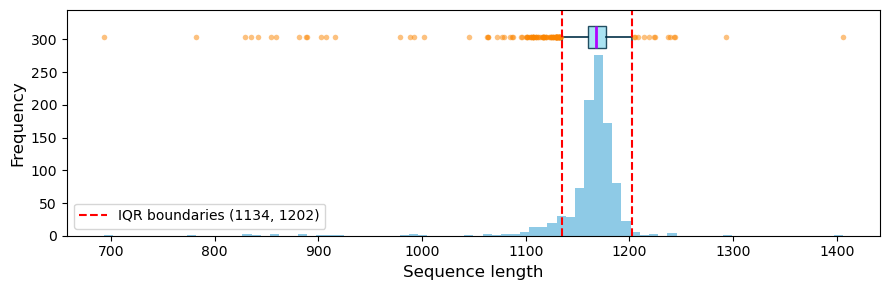

In [65]:
import numpy as np
import matplotlib.pyplot as plt

lengths = df_interpro['length']

# IQR fences
q1, q3 = np.percentile(lengths, [25, 75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

fig, ax = plt.subplots(figsize=(9, 3))

# Histogram on the main axis
counts, _, _ = ax.hist(lengths, bins=80, color='#8ecae6')
ymax = counts.max()

# Styling for each boxplot element
box_style = dict(facecolor="#9bdff0", edgecolor='#023047', alpha=0.85)
median_style = dict(color="#af03ff", linewidth=2)
line_style = dict(color='#023047', linewidth=1.2)
flier_style = dict(marker='o', markersize=4, markerfacecolor='#fb8500',
                   markeredgecolor='none', alpha=0.5)

# Float the box in the empty band above the bars, same axis
ax.boxplot(
    lengths, orientation='horizontal', whis=1.5,
    positions=[ymax * 1.1], widths=ymax * 0.12, manage_ticks=False,
    patch_artist=True,
    boxprops=box_style, medianprops=median_style,
    whiskerprops=line_style, capprops=line_style, flierprops=flier_style,
)

# IQR fences
ax.axvline(lower, color='red', ls='--', lw=1.5, label=f'IQR boundaries ({lower:.0f}, {upper:.0f})')
ax.axvline(upper, color='red', ls='--', lw=1.5)

ax.set_ylim(0, ymax * 1.25)
# ax.set_title('Distribution of CAR-like sequence lengths', fontsize=15)
ax.set_xlabel('Sequence length', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('../figs/homologs_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
from Bio import SeqIO

records = list(SeqIO.parse("car_interpro.fasta", "fasta"))
for rec in records:
    print(rec.id, len(rec.seq), rec.seq[:50])

len(records)

A0A010YLP6|unreviewed|Carrier 1152 MTHTDQGDVTTVAERRALLLEQDEQFASAVPDDHVTALVRQPTMSLEAVV
A0A024JSK2|unreviewed|Carboxylic 1188 MTTDMKRENGTNSTTKATPRERVAERIRRVEATDEQYRNAKPDQALRAAA
A0A024JWI0|unreviewed|Carboxylic 1162 MSTTTREERLERRIENLTATDPQFAAAKPDPAVVEALEQPGLQLPQIIQT
A0A024JZE3|unreviewed|Carboxylic 1165 MAFVGRSDVKDPGAQQDQWERLARRRERLYAEDAQFAATRPDEQIAAAAR
A0A024JZE8|unreviewed|Carboxylic 1182 MTSGSLRDIHLAEPGDNRDERTAQRVAELFDNDPQFRAAAPLPDVIEAAC
A0A045K2P5|unreviewed|Carboxylic 1168 MSINDQRLTRRVEDLYASDAQFAAASPNEAITQAIDQPGVALPQLIRMVM
A0A051U3G5|unreviewed|Carboxylic 1170 MSTAIHDEELDRRIEHLVATDPQFAATRPDPAITAATEQPGLRLPQIIRT
A0A051UFG9|unreviewed|Carboxylic 1193 MTDDAKRAKVSSTGPISAARQQVADRIRDLDARDEEFRTTKPDSALQLAA
A0A064CG00|unreviewed|Carboxylic 1164 MPTDTREARFEQRVADLYTSDPQFAAAAPDPQVTAAAATPGLPLSAVITT
A0A0B1ZH49|unreviewed|Carrier 1180 MTTAVAENPKKTAIFTGGKQTKWAEERLEKLKSEDRQFIAALPDPAVVEA
A0A0B1ZIQ0|unreviewed|Carrier 1135 MDAESGVMPSDPDVVAFVRRPDTCLSAMIEKALDSYAGRDALAWRPTRSG
A0A0B8NM02|unreviewed|Carboxyl

1026